In [8]:
# Import your existing types and functions
from typing import Optional, Union, Any
from dataclasses import dataclass
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

import pandas as pd
import torch
from torch import Tensor, einsum
from jaxtyping import Float, Int, Bool

from js_embedding_vis import write_inlined_config

from muutils.collect_warnings import CollateWarnings
from muutils.dbg import dbg, dbg_auto, dbg_tensor
import matplotlib.pyplot as plt


from spd.analysis.embed_vis import AnalysisConfig, coactivation_analysis, plot_embedding_label_grid
from spd.analysis.grouping import (
    CoactivationResults,
    CoactivationResultsGroup,
    get_coactivations,
    compute_merge_costs,
)
from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.utils import get_device_torch
from spd.analysis.merge_matrix import GroupMerge, BatchedGroupMerge

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE = get_device_torch()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = device(type='cuda')


In [4]:
COACTIVATIONS = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
	dataloader_kwargs=dict(
		batch_size=100,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
		n_samples=100,
    ),
    device=DEVICE,
)["group_0"]



dbg_auto(COACTIVATIONS);

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/muutils/tensor_info.py:260: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bins = np.histogram(A_hist, bins=hist_bins)
[ <ipykernel>:24 ] COACTIVATIONS: <dict of len()=12, key_types={str}, val_types={Tensor, dict, float, int, list, ndarray}>
  co_occurrence_matrix: μ=0.39 σ=1.46 x̃=0.00 R=[0.00,24.00] ℙ˪=|█▅▅▃▂▁▁| shape=(200,200) dtype=torch.float32 device=cuda:0 ∇✗
  marginal_counts: μ=4.05 σ=6.46 x̃=0.50 R=[0.00,24.00] ℙ=|█  ▁▁  | shape=200 dtype=torch.float32 device=cuda:0 ∇✗
  module_slices:   <dict of len()=2, key_types={str}, val_types={slice}>
    layers.0.mlp_in: slice(0, 100, None)
    layers.0.mlp_out: slice(100, 200, None)
  modules: ['layers.0.mlp_in', 'layers.0.mlp_out']
  labels: shape=200 dtype=<U16
  component_masks: μ=0.02 σ=0.12 x̃=-0.00 R=[-0.05,1.00] ℙ˪=|█▄▄▄▃▄▄| shape=(100,200) dtype=torch.float32 device=cuda:0 ∇✗
  active_mask: μ=0.04 σ=0.20 x̃=0.00 R=[0,

the above actually makes sense. the last 100 are the superimposed components which we expect to merge into one super-component.	

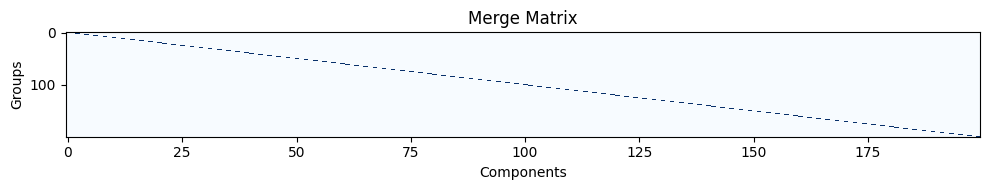

[ <ipykernel>:10 ] gm_downstream.group_idxs: μ=98.83 σ=57.45 x̃=99.00 R=[0,198] ℙ=|███████| shape=(19900,200) dtype=torch.int64 device=cpu ∇✗
[ <ipykernel>:11 ] "d" = 'd'
[ <ipykernel>:13 ] "e" = 'e'
[ <ipykernel>:14 ] gmd_m: μ=98.83 σ=57.45 x̃=99.00 R=[0,198] ℙ=|███████| shape=(19900,200) dtype=torch.int64 device=cpu ∇✗


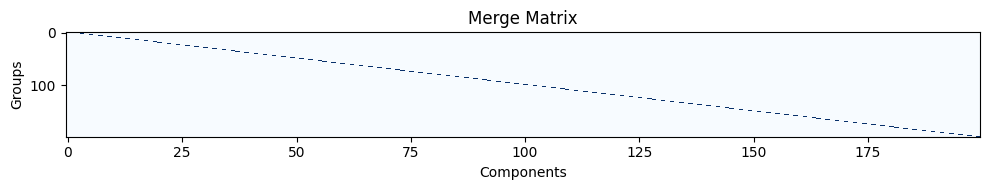

In [5]:
# gm = GroupMerge.random(
#     n_components=200,
#     k_groups=50,
#     ensure_groups_nonempty=True,
# )
gm = GroupMerge.identity(n_components=200)

gm.plot(figsize=(10, 2))
gm_downstream: BatchedGroupMerge = gm.all_downstream_merged()
dbg_tensor(gm_downstream.group_idxs);
dbg("d")
gmd_m = gm_downstream.group_idxs
dbg("e")
dbg_tensor(gmd_m);
gm_downstream[0].plot(figsize=(10, 2))


# From `NewPD.pdf`, section 6.1:

We want to minimise

$$
   \mathcal{L} (x)=
   \sum_{c}
   \lVert s_c(x) \rVert_0
   \left(
      1 + \alpha \sum_l r(P_c)
   \right)
$$

where $s_{c}(x)$ are the component masks.
When we merge two components $P_{c_1}$ and $P_{c_2}$ into one

$$
   P_{c_3} = P_{c_1} + P_{c_2}
$$

we set the mask of the new component to

$$
   s_{c_3}(x) = \max \{ s_{c_1}(x), s_{c_2}(x) \}
$$

Accordingly, the difference in description length from merging $P_{c_1}$ and $P_{c_2}$ is

$$
   F(P_{c_1}, P_{c_2}) :=
   \bigg[
      \alpha \lVert s_{c_1} \rVert_0  r(P_{c_2})
      +\alpha \lVert s_{c_2} \rVert_0 r(P_{c_1})
   \bigg]
   - \Bigg[
      s_{c_1} s_{c_2}
      \Big(
         \alpha r(P_{c_1}) + \alpha r(P_{c_2}) + 1
      \Big)
   \Bigg]
$$

Note that this assumes $r(P_{c_3}) = r(P_{c_1} + P_{c_2})$, which is likely safe because the APD training discourages creating components where this would not hold.


# over a dataset

We care about the expected over a dataset $\mathcal{D}$, where $x \sim \mathcal{D}$. The ranks of the components are fine, looking at $s_{c_i}(x)$ for each sample is *really expensive.* When each $P_c$ is unmerged, and has rank 1, everything is relatively easy.


$$
    F(P_{c_1}, P_{c_2}) :=
    \mathbb{E}_{x \sim \mathcal{D}}
    \Bigg[
        \bigg[
            \alpha \lVert s_{c_1} \rVert_0  r(P_{c_2})
            +\alpha \lVert s_{c_2} \rVert_0 r(P_{c_1})
        \bigg]
        - \bigg[
            s_{c_1} s_{c_2}
            \Big(
                \alpha r(P_{c_1}) + \alpha r(P_{c_2}) + 1
            \Big)
        \bigg]
    \Bigg]
$$

$$
	= \mathbb{E}_{x \sim \mathcal{D}}
    \Bigg[
        \alpha \bigg[
            \lVert s_{c_1} \rVert_0  r(P_{c_2})
            + \lVert s_{c_2} \rVert_0 r(P_{c_1})
        \bigg]
        - \bigg[
            \alpha s_{c_1} s_{c_2}
            \Big(
                r(P_{c_1}) + r(P_{c_2}) + \alpha^{-1}
            \Big)
        \bigg]
    \Bigg]
$$

$$
	= \alpha \cdot \mathbb{E}_{x \sim \mathcal{D}}
    \Bigg[
        \bigg[
            \lVert s_{c_1} \rVert_0  r(P_{c_2})
            + \lVert s_{c_2} \rVert_0 r(P_{c_1})
        \bigg]
        - \bigg[
            s_{c_1} s_{c_2}
            \Big(
                r(P_{c_1}) + r(P_{c_2}) + \alpha^{-1}
            \Big)
        \bigg]
    \Bigg]
$$

$$
	\approx \frac{\alpha}{n} \cdot \sum_{x \sim_n \mathcal{D}}
    \Bigg[
        \bigg[
            \lVert s_{c_1}(x) \rVert_0  r(P_{c_2})
            + \lVert s_{c_2}(x) \rVert_0 r(P_{c_1})
        \bigg]
        - \bigg[
            s_{c_1}(x) s_{c_2}(x)
        \bigg]
        \Big(
            r(P_{c_1}) + r(P_{c_2}) + \alpha^{-1}
        \Big)
    \Bigg]
$$

$$
	\approx \frac{\alpha}{n}
    \Bigg[
        \sum_{x \sim_n \mathcal{D}} \bigg[
            \lVert s_{c_1}(x) \rVert_0  r(P_{c_2})
		\bigg]
		+ \sum_{x \sim_n \mathcal{D}} \bigg[
            \lVert s_{c_2}(x) \rVert_0 r(P_{c_1})
        \bigg]
        - \sum_{x \sim_n \mathcal{D}} \bigg[
            s_{c_1}(x) s_{c_2}(x)
        \bigg]
        \Big(
            r(P_{c_1}) + r(P_{c_2}) + \alpha^{-1}
        \Big)
    \Bigg]
$$

$$
	\approx \frac{\alpha}{n}
    \Bigg[
        r(P_{c_2}) \sum_{x \sim_n \mathcal{D}} \bigg[
            \lVert s_{c_1}(x) \rVert_0
		\bigg]
		+ r(P_{c_1}) \sum_{x \sim_n \mathcal{D}} \bigg[
            \lVert s_{c_2}(x) \rVert_0
        \bigg]
		- \Big(
			r(P_{c_1}) + r(P_{c_2}) + \alpha^{-1}
		\Big)
        \cdot \sum_{x \sim_n \mathcal{D}} \bigg[
            s_{c_1}(x) s_{c_2}(x)
        \bigg]
    \Bigg]
$$

If we take $a_{c_i} := \sum_{x \sim_n \mathcal{D}} \lVert s_{c_i}(x) \rVert_0$ (the number of samples on which the component $c_i$ is active), we can rewrite this as
$$
	\approx \frac{\alpha}{n}
    \Bigg[
        r(P_{c_2}) a_{c_1}
		+ r(P_{c_1}) a_{c_2}
		- \Big(
			r(P_{c_1}) + r(P_{c_2}) + \alpha^{-1}
		\Big)
        \cdot \sum_{x \sim_n \mathcal{D}} \bigg[
            s_{c_1}(x) s_{c_2}(x)
        \bigg]
    \Bigg]
$$

## Assuming Boolean Activations

Now, if we make the assumption that $s_{c_i}(x) \in \{0, 1\}$, (that is, all activation are boolean), then the following term is essentially the sum over an `AND` operation over the activation masks for the two components:
$$
	\sum_{x \sim_n \mathcal{D}} \bigg[
		s_{c_1}(x) s_{c_2}(x)
	\bigg]
$$

We note that if we consider the co-activation matrix
$$
	A_* \in \R^{c \times c}
	\qquad \text{where} \qquad
	A_*[i,j] = \sum_{x \sim_n \mathcal{D}} \big[
		s_{c_1}(x) \cdot s_{c_2}(x)
	\big]
	= S_{c_i} \cdot S_{c_j}
$$
then we also get $a_{c_i} = A[i,i]$.

$$
	F(P_{c_i}, P_{c_j}) := \frac{\alpha}{n}
    \Bigg[
        r(P_{c_j}) A[i,i]
		+ r(P_{c_i}) A[j,j]
		- \Big(
			r(P_{c_i}) + r(P_{c_j}) + \alpha^{-1}
		\Big)
        \cdot A[i,j]
    \Bigg]
$$

However, we need to account for merges. Let's denote the space of merges $M$, where each merge $g \in M$ can be represented either as a matrix
$$
	g \in \{0, 1\}^{k \times c}
$$
where $c$ is our original number of components, and $k$ is the number of groups of merged components. $g$ is one-hot for each component:
$$
	\sum g[:,j] = 1
$$
and $g[i,j] = 1$ if component $c_j$ is merged into group $i$ and $0$ otherwise. We will denote the "identity" merge where no components have been merged as $g_0 := \mathbb{I}_c$, where $k_0 = c$ and $g_0[i,i] = 1$ for all $i$ and $0$ otherwise.

We might also represent a merge as $\hat{g}$, where $\hat{g} \in \N_k^c$. In this case, $\hat{g}[j]$ is the group into which component $c_j$ is merged.

Furthermore, we can define a function $G : M \times \N_k \to \mathbb{P}^{\N_c}$ which takes a merge $g$ and a group index $i$ and returns the components in group $i$:
$$
	G(g, i) = \{ j \in \N_c : g[i,j] = 1 \}
$$

We can now define a co-activation *function* which returns a matrix of coactivation values for a given merge $g$:
$$
	A : M \to \R^{k \times k}
	\qquad \text{where} \qquad
	A(g)[i,j] = \sum_{x \sim_n \mathcal{D}} \big[
		\max([s_u(x)]_{u \in G(g, i)})
		\cdot \max([s_v(x)]_{v \in G(g, j)})
	\big]
$$



$$
	= \sum_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod_{u \in G(g, i)} (1 - s_u(x))
		\Bigg] \cdot \Bigg[
		1 - \prod_{v \in G(g, j)} (1 - s_v(x))
	\Bigg]
$$



Now, recomputing the co-activation matrix at every iteration is expensive. However, let's start with the co-activation matrix $A(g)$ for some merge $g$ (this might be the identity merge $g_0$). What we want is compute the co-activation matrix for some new merge $g_{m(i,j)}$ where we have merged groups $i$ and $j$ into a new group $k$. That is,
$$
	g_{m(i,j)}[k,:] = \max(g[i,:], g[j,:])
$$
> Note: the indexing here is tricky if we want to be efficient. Here, we assume that all indicies besides $i,j,k$ are completely unchanged. You can think of this as adding $k$ onto the end so no previous indices change.

We can now state $A(g_{m(i,j)})$ as follows:
$$
	A(g_{m(i,j)})[k,l] = \sum_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod_{u \in G(g_{m(i,j)}, k)} (1 - s_u(x))
		\Bigg] \cdot \Bigg[
		1 - \prod_{v \in G(g_{m(i,j)}, l)} (1 - s_v(x))
	\Bigg]
$$

Now, we can factor out the cases with the common terms between $g$ and $g_{m(i,j)}$ -- which is everything besides $i,j$, and our new index $k$ they are merged into.

$$
	G(g_{m(i,j)}, l) = \begin{cases} 
		G(g, l) & \text{if } l \not\in \{i,j,k\} \\
		G(g, i) \lor G(g, j) & \text{if } l = k \\
		\texttt{undefined} & \text{if } l \in \{i,j\}
	\end{cases}
$$

So, notably, 
$$
	G(g_{m(i,j)}, l) = G(g, l)
	\qquad \text{if } \qquad
	l \not\in \{i,j,k\}
$$

$$
	A(g_{m(i,j)})[l,m] =
	\begin{cases}
		\text{if} \quad
			\{l \lor m\} \not\in \{i,j,k\}
			&: \quad A(g)[l,m] \\
		\text{if } \quad
			\{l \lor m\} \in \{i,j\}
			&: \quad \texttt{undefined} \\
		\text{if } \quad
			\{l \lor m\} == k
			&: \quad H(g_{m(i,j)}, l, m) \\
	\end{cases}
$$

Where
$$
	H(g_{m(i,j)}, l, m) :=
	\sum\limits_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod\limits_{u \in G(g_{m(i,j)}, l)} (1 - s_u(x))
		\Bigg] \cdot \Bigg[
		1 - \prod\limits_{v \in G(g_{m(i,j)}, m)} (1 - s_v(x))
	\Bigg]
$$

We can further do some casework here. if $l = m = k$, we get
$$
	H(g_{m(i,j)}, l=k, m=k) =
	\sum\limits_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod\limits_{
			u \in (G(g, i) \lor G(g, j))
		} (1 - s_u(x))
		\Bigg] \cdot \Bigg[
		1 - \prod\limits_{
			v \in (G(g, i) \lor G(g, j))
		} (1 - s_v(x))
	\Bigg]
$$
$$
	= \sum\limits_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod\limits_{
			v \in (G(g, i) \lor G(g, j))
		} (1 - s_v(x))
	\Bigg]^2
$$

If we assume $l = k$ and $m \neq k$ (the reverse case is identical, since the matrix is symmetric), we get
$$
	H(g_{m(i,j)}, l=k, m\neq k) :=
	\sum\limits_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod\limits_{
			u \in (G(g, i) \lor G(g, j))
		} (1 - s_u(x))
		\Bigg] \cdot \Bigg[
		1 - \prod\limits_{
			v \in G(g, m)
		} (1 - s_v(x))
	\Bigg]
$$

$$
	A(g_{m(i,j)})[l,m] = \sum_{x \sim_n \mathcal{D}} \Bigg[
		1 - \prod_{u \in G(g_{m(i,j)}, l)} (1 - s_u(x))
		\Bigg] \cdot \Bigg[
		1 - \prod_{v \in G(g_{m(i,j)}, m)} (1 - s_v(x))
	\Bigg]
$$

$$
	A(g_{m(i,j)})[u,v] =
	\begin{cases}
		A(g)[u,v] & \text{if} \ u,v \not\in \{i,j,k\} \\
		\text{null} & \text{if} u,v \in \{i,j\} \\

	\end{cases}
$$

In [ ]:

def merge_iteration(
    active_mask: Bool[Tensor, "samples n_components"],
    coact: Float[Tensor, "n_components n_components"],
    target_k: int,
    alpha: float = 1.0,
) -> dict[str, Any]:
    n_samples: int = active_mask.shape[0]
    n_components: int = active_mask.shape[1]
    assert n_components == coact.shape[0] == coact.shape[1]

    current_k: int = n_components
    group_active_mask: Bool[Tensor, "n_samples current_k"] = active_mask.clone()
    group_coact: Float[Tensor, "current_k current_k"] = coact.clone()
    current_merge: GroupMerge = GroupMerge.identity(n_components)

    while current_k > target_k:
        # sanity checks
        assert current_k == current_merge.k_groups
        assert group_active_mask.shape[1] == current_k
        assert group_coact.shape[0] == group_coact.shape[1] == current_k

        merge_costs: Float[Tensor, "current_k current_k"] = torch.full(
            (current_k, current_k),
            float("inf"),
            device=active_mask.device,
        )
        group_ranks: Int[Tensor, "current_k"] = current_merge.components_per_group

        # compute merge costs for all pairs
        for i in range(current_merge.k_groups):
            for j in range(current_merge.k_groups):
                # eq 25 in NewPD.pdf
                merge_cost_ij: float = (
                    
                )
                



    return {}

    


In [6]:
dbg_tensor(COACTIVATIONS['active_mask'])
merge_costs = compute_merge_costs(
    activation_mask=COACTIVATIONS['active_mask'],
    bgm=gm_downstream,
    alpha=1.0,
)
dbg_tensor(merge_costs);

[ <ipykernel>:1 ] COACTIVATIONS['active_mask']: μ=0.04 σ=0.20 x̃=0.00 R=[0,1] ℙ˪=|█     ▅| shape=(100,200) dtype=torch.bool device=cuda:0 ∇✗
[ /home/miv/projects/MATS/apd/spd/analysis/grouping.py:491 ] activation_mask: μ=0.04 σ=0.20 x̃=0.00 R=[0,1] ℙ˪=|█     ▅| shape=(100,200) dtype=torch.bool device=cuda:0 ∇✗
[ /home/miv/projects/MATS/apd/spd/analysis/grouping.py:492 ] (bgm.batch_size, bgm.k_groups_unique, n_components) = (19900, 199, 200)


OutOfMemoryError: CUDA out of memory. Tried to allocate 73.76 GiB. GPU 0 has a total capacity of 15.62 GiB of which 13.91 GiB is free. Including non-PyTorch memory, this process has 1.69 GiB memory in use. Of the allocated memory 779.64 MiB is allocated by PyTorch, and 756.36 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
n_downstream: int = gm.k_groups
merge_costs_grid = torch.full((n_downstream, n_downstream), torch.nan)
for g in range(gm_downstream.batch_size):
    mp = gm_downstream.meta[g]['merge_pair']
    merge_costs_grid[mp] = merge_costs[g].cpu()
    merge_costs_grid[mp[1], mp[0]] = merge_costs[g].cpu()

plt.matshow(merge_costs_grid)
plt.colorbar(label='Merge Cost')

In [ ]:
def greedy_merge(
	activation_mask: Bool[Tensor, "n_samples n_components"],
	target_k_groups: int,
    alpha: float = 1.0,
	initial_guess: GroupMerge|None = None,
):
	n_samples: int; n_components: int
	n_samples, n_components = activation_mask.shape

	current_merge: GroupMerge
	if initial_guess is None:
		current_merge = GroupMerge.identity(n_components)
	else:
		current_merge = initial_guess


	dbg_tensor(current_merge.to_matrix())

	while current_merge.k_groups > target_k_groups:
		# Compute merge costs for all pairs of groups
		adm: BatchedGroupMerge = current_merge.all_downstream_merged()
		dbg_tensor(adm.to_matrix())
		merge_costs: Tensor = compute_merge_costs(
			activation_mask=activation_mask,
			bgm=adm,
			alpha=alpha,
		)

		# Find the pair with the lowest merge cost
		min_cost, min_pair = torch.min(merge_costs, dim=0)
		dbg(min_cost)
		dbg(min_pair)

		# Merge the pair with the lowest cost
		current_merge = current_merge.merge_groups(min_pair)
		dbg(f"Merging {min_pair} with cost {min_cost.item()}")
		dbg_tensor(current_merge.to_matrix())



greedy_merge(COACTIVATIONS['active_mask'], 10)

In [ ]:


def generate_all_merge_matrices(n_components: int, k: int, device=None) -> Bool[Tensor, "n_matrices k n_components"]:
    """Generate all possible merge matrices as single tensor"""
    if device is None:
        device = torch.device('cpu')
    
    # Total possibilities: k^n_components
    n_total = k ** n_components
    
    # Generate all base-k assignments
    assignments = torch.zeros(n_total, n_components, dtype=torch.long, device=device)
    
    for i in range(n_total):
        temp = i
        for j in range(n_components):
            assignments[i, j] = temp % k
            temp //= k
    
    # Convert to one-hot merge matrices
    merge_matrices = torch.zeros(n_total, k, n_components, dtype=torch.bool, device=device)
    batch_indices = torch.arange(n_total, device=device).unsqueeze(1)  # [n_total, 1]
    component_indices = torch.arange(n_components, device=device).unsqueeze(0)  # [1, n_components]
    
    merge_matrices[batch_indices, assignments, component_indices] = True
    
    # Filter out matrices with empty groups
    group_counts = merge_matrices.sum(dim=2)  # [n_total, k]
    valid_mask = (group_counts > 0).all(dim=1)  # [n_total]
    
    return merge_matrices[valid_mask]


def find_all_merge_costs(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    k: int,
    alpha: float = 1.0,
) -> Float[Tensor, "n_matrices"]:
    """Return costs for all possible merge matrices"""
    all_matrices = generate_all_merge_matrices(marginal_counts.shape[0], k, marginal_counts.device)
    return compute_merge_costs(co_occurrence_matrix, marginal_counts, all_matrices, alpha)


def greedy_merge_search(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    k: int,
    alpha: float = 1.0,
    temperature: float = 0.0,
    seed: Optional[int] = None,
) -> tuple[Bool[Tensor, "k n_components"], float]:
    """Greedy search with optional temperature sampling"""
    if seed is not None:
        torch.manual_seed(seed)
    
    n_components = marginal_counts.shape[0]
    device = marginal_counts.device
    
    # Start with identity
    merge_matrix = torch.eye(n_components, dtype=torch.bool, device=device)
    current_k = n_components
    
    while current_k > k:
        # Generate all possible merge candidates
        candidates = []
        
        for i in range(current_k):
            for j in range(i + 1, current_k):
                # Create candidate by merging groups i and j
                candidate = merge_matrix.clone()
                candidate[i] = candidate[i] | candidate[j]
                
                # Remove group j by shifting
                if j < current_k - 1:
                    candidate[j:current_k-1] = candidate[j+1:current_k]
                candidate = candidate[:current_k-1]
                
                candidates.append(candidate)
        
        # Compute costs for all candidates
        if len(candidates) > 0:
            candidate_stack = torch.stack(candidates)  # [n_candidates, current_k-1, n_components]
            
            # Compute current cost
            current_cost = compute_merge_costs(co_occurrence_matrix, marginal_counts, merge_matrix, alpha)
            
            # Compute candidate costs
            candidate_costs = compute_merge_costs(co_occurrence_matrix, marginal_counts, candidate_stack, alpha)
            cost_deltas = candidate_costs - current_cost
            
            # Select based on temperature
            if temperature == 0.0:
                best_idx = cost_deltas.argmin().item()
            else:
                probs = torch.softmax(-cost_deltas / temperature, dim=0)
                best_idx = torch.multinomial(probs, 1).item()
            
            merge_matrix = candidates[best_idx]
            current_k -= 1
        else:
            break
    
    final_cost = compute_merge_costs(co_occurrence_matrix, marginal_counts, merge_matrix, alpha)
    return merge_matrix, final_cost